In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
df = pd.read_csv("/content/Lung_Disease_Dataset.csv")
df.head()

,Unnamed: 0,ID,AGE,PackHistory,COPDSEVERITY,MWT1,MWT2,MWT1Best,FEV1,FEV1PRED,...,SGRQ,AGEquartiles,copd,gender,smoking,Diabetes,muscular,hypertension,AtrialFib,IHD
0,1,58,77,60.0,SEVERE,120.0,120.0,120.0,1.21,36.0,...,69.55,4,3,1,2,1,0,0,1,0
1,2,57,79,50.0,MODERATE,165.0,176.0,176.0,1.09,56.0,...,44.24,4,2,0,2,1,0,0,1,1
2,3,62,80,11.0,MODERATE,201.0,180.0,201.0,1.52,68.0,...,44.09,4,2,0,2,1,0,0,1,0
3,4,145,56,60.0,VERY SEVERE,210.0,210.0,210.0,0.47,14.0,...,62.04,1,4,1,2,0,0,1,1,0
4,5,136,65,68.0,SEVERE,204.0,210.0,210.0,1.07,42.0,...,75.56,1,3,1,2,0,1,1,0,0


In [ ]:
print(df.shape)
df.info()
df.describe()

(101, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    101 non-null    int64  
 1   ID            101 non-null    int64  
 2   AGE           101 non-null    int64  
 3   PackHistory   101 non-null    float64
 4   COPDSEVERITY  101 non-null    object 
 5   MWT1          99 non-null     float64
 6   MWT2          100 non-null    float64
 7   MWT1Best      100 non-null    float64
 8   FEV1          101 non-null    float64
 9   FEV1PRED      101 non-null    float64
 10  FVC           101 non-null    float64
 11  FVCPRED       101 non-null    int64  
 12  CAT           101 non-null    int64  
 13  HAD           101 non-null    float64
 14  SGRQ          101 non-null    float64
 15  AGEquartiles  101 non-null    int64  
 16  copd          101 non-null    int64  
 17  gender        101 non-null    int64  
 18  smoking       101 no

,Unnamed: 0,ID,AGE,PackHistory,MWT1,MWT2,MWT1Best,FEV1,FEV1PRED,FVC,...,SGRQ,AGEquartiles,copd,gender,smoking,Diabetes,muscular,hypertension,AtrialFib,IHD
count,101.000000,101.000000,101.00000,101.000000,99.000000,100.000000,100.000000,101.000000,101.000000,101.000000,...,101.000000,101.000000,101.00000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,51.000000,91.405941,70.09901,39.698020,385.858586,390.280000,399.110000,1.603762,58.531485,2.954950,...,40.185842,2.475248,2.19802,0.643564,1.841584,0.207921,0.188119,0.118812,0.198020,0.089109
std,29.300171,51.516246,7.89874,24.558713,104.744199,107.754498,106.550116,0.672763,22.294821,0.976283,...,18.239268,1.109901,0.88340,0.481335,0.366952,0.407844,0.392756,0.325181,0.400495,0.286322
min,1.000000,1.000000,44.00000,1.000000,120.000000,120.000000,120.000000,0.450000,3.290000,1.140000,...,2.000000,1.000000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,26.000000,49.000000,65.00000,20.000000,300.000000,303.750000,303.750000,1.100000,42.000000,2.270000,...,28.410000,1.000000,2.00000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,51.000000,87.000000,71.00000,36.000000,419.000000,399.000000,420.000000,1.600000,60.000000,2.770000,...,38.210000,3.000000,2.00000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,76.000000,143.000000,75.00000,54.000000,460.500000,459.000000,465.250000,1.960000,75.000000,3.630000,...,55.230000,3.000000,3.00000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,101.000000,169.000000,88.00000,109.000000,688.000000,699.000000,699.000000,3.180000,102.000000,5.370000,...,77.440000,4.000000,4.00000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
df['COPDSEVERITY'].unique()

array(['SEVERE', 'MODERATE', 'VERY SEVERE', 'MILD'], dtype=object)

In [ ]:
df['COPDSEVERITY'] = df['COPDSEVERITY'].replace({
    'MILD':0,
    'MODERATE':1,
    'SEVERE':2,
    'VERY SEVERE':3
}).astype(int)

/tmp/ipykernel_524/2937717302.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['COPDSEVERITY'] = df['COPDSEVERITY'].replace({


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    101 non-null    int64  
 1   ID            101 non-null    int64  
 2   AGE           101 non-null    int64  
 3   PackHistory   101 non-null    float64
 4   COPDSEVERITY  101 non-null    int64  
 5   MWT1          101 non-null    float64
 6   MWT2          101 non-null    float64
 7   MWT1Best      101 non-null    float64
 8   FEV1          101 non-null    float64
 9   FEV1PRED      101 non-null    float64
 10  FVC           101 non-null    float64
 11  FVCPRED       101 non-null    int64  
 12  CAT           101 non-null    int64  
 13  HAD           101 non-null    float64
 14  SGRQ          101 non-null    float64
 15  AGEquartiles  101 non-null    int64  
 16  copd          101 non-null    int64  
 17  gender        101 non-null    int64  
 18  smoking       101 non-null    

In [ ]:
df.drop(['Unnamed: 0','ID'], axis=1, inplace=True)

In [ ]:
df.rename(columns={'copd':'Target'}, inplace=True)

In [ ]:
X = df.drop("Target", axis=1)
y = df["Target"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(max_iter=5000))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic', LogisticRegression(max_iter=5000))])

In [ ]:
y_pred_log = log_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_log = accuracy_score(y_test, y_pred_log)
pre_log = precision_score(y_test, y_pred_log, average='weighted')
rec_log = recall_score(y_test, y_pred_log, average='weighted')
f1_log = f1_score(y_test, y_pred_log, average='weighted')

print("Accuracy:", acc_log)
print("Precision:", pre_log)
print("Recall:", rec_log)
print("F1 Score:", f1_log)

Accuracy: 0.8095238095238095
Precision: 0.8432539682539684
Recall: 0.8095238095238095
F1 Score: 0.8191268426562544


In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

svm_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC())])

In [ ]:
y_pred_svm = svm_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_svm = accuracy_score(y_test, y_pred_svm)
pre_svm = precision_score(y_test, y_pred_svm, average='weighted')
rec_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
pre_dt = precision_score(y_test, y_pred_dt, average='weighted')
rec_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
pre_rf = precision_score(y_test, y_pred_rf, average='weighted')
rec_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Decision Tree", "Random Forest"],
    "Accuracy": [acc_log, acc_svm, acc_dt, acc_rf],
    "Precision": [pre_log, pre_svm, pre_dt, pre_rf],
    "Recall": [rec_log, rec_svm, rec_dt, rec_rf],
    "F1 Score": [f1_log, f1_svm, f1_dt, f1_rf]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.809524,0.843254,0.809524,0.819127
1,SVM,0.809524,0.863095,0.809524,0.806166
2,Decision Tree,1.000000,1.000000,1.000000,1.000000
3,Random Forest,0.952381,0.960317,0.952381,0.951900


<Axes: title={'center': 'Feature Importance for Lung Disease Prediction'}>

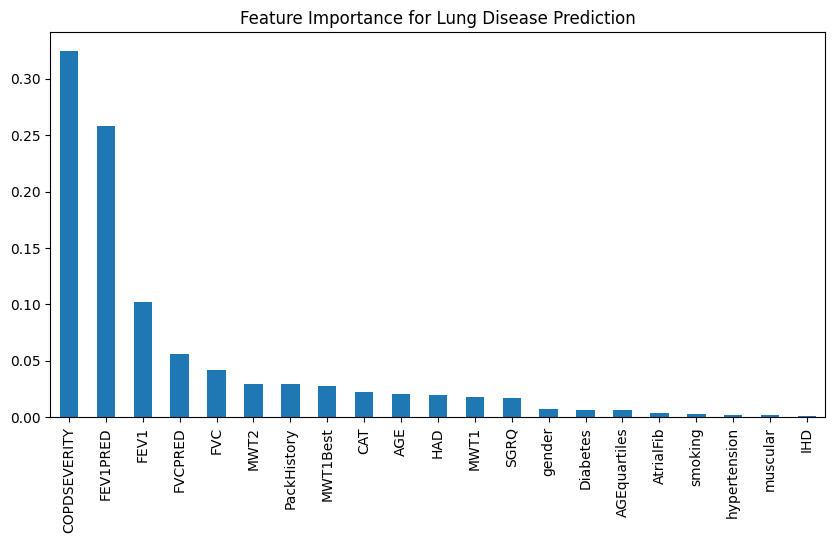

In [ ]:
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)

feature_importance.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,5),
    title="Feature Importance for Lung Disease Prediction"
)

In [ ]:
import joblib

joblib.dump(rf_model, "lung_model.pkl")

['lung_model.pkl']

In [ ]:
final_summary = pd.DataFrame({
    "Disease": ["Diabetes", "Kidney", "Lung"],
    "Best Model": ["Logistic Regression", "Random Forest", "Random Forest"],
    "Accuracy": [0.82, 0.96, 0.91]
})

final_summary

,Disease,Best Model,Accuracy
0,Diabetes,Logistic Regression,0.82
1,Kidney,Random Forest,0.96
2,Lung,Random Forest,0.91


In [ ]:
import joblib
joblib.dump(rf_model, "lung_model.pkl")

['lung_model.pkl']

In [ ]:
from google.colab import files
files.download("lung_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>